In [1]:
import pandas as pd
df = pd.read_excel('pisa3.xlsx')
df

,jurisdiction,gender,subject,year,average,std error
0,Australia,all,mathematics,2000,NaN,NaN
1,Australia,all,mathematics,2003,524.266004,2.148447
2,Australia,all,mathematics,2006,519.907749,2.240618
3,Australia,all,mathematics,2009,514.340462,2.528262
4,Australia,all,mathematics,2012,504.150766,1.643078
...,...,...,...,...,...,...
2803,United States,female,science,2009,494.952023,3.710066
2804,United States,female,science,2012,498.325372,3.954331
2805,United States,female,science,2015,492.865072,3.403776
2806,United States,female,science,2018,502.001844,3.479127


Let's plot all data in a lineplot!

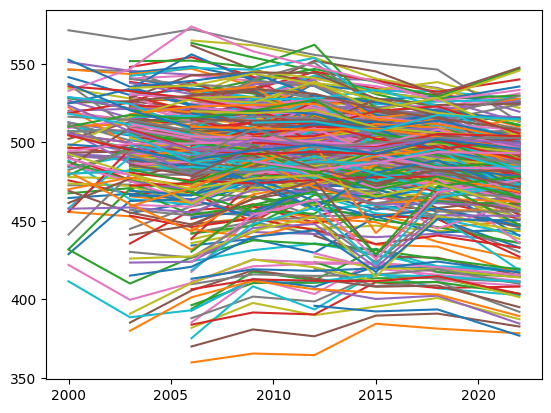

In [2]:
import matplotlib.pyplot as plt
from itertools import product
years = df['year'].unique()
countries = df['jurisdiction'].unique()
genders = df['gender'].unique()
subjects = df['subject'].unique()
xs = years
for (country, gender, subject) in product(countries,genders,subjects):
    ys = df[(df['jurisdiction'] == country) & (df['gender'] == gender) & (df['subject'] == subject)]['average']
    label = f'{country}/{gender}/{subject}'
    plt.plot(xs,ys,label=label)

This plot is impossible to make heads or tails about:
- there's *way* too many lines
- it contains incompatible data (different subject scores, different gender groupings)
- axes are unlabelled
- there's no legend, so we have no idea what each line represents (not that we could tell even if we had)

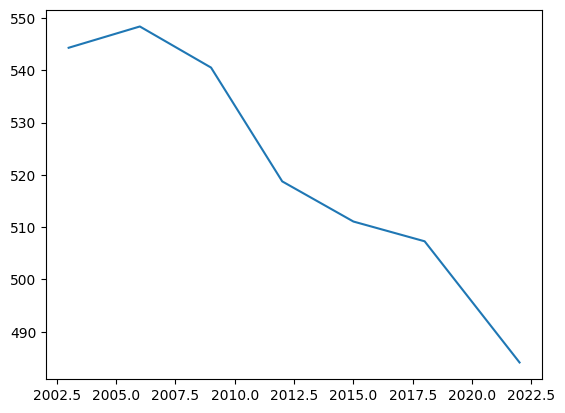

In [3]:
xs = years
ys = df.query('jurisdiction == "Finland" and gender == "all" and subject == "mathematics"')['average']
plt.plot(xs,ys)

This is a lot better. This tells clearly a story: something's going downhill. But what exactly? Let's label the axes and give the figure a descriptive title.

Text(0.5, 1.0, 'PISA score in mathematics in Finland (all genders)')

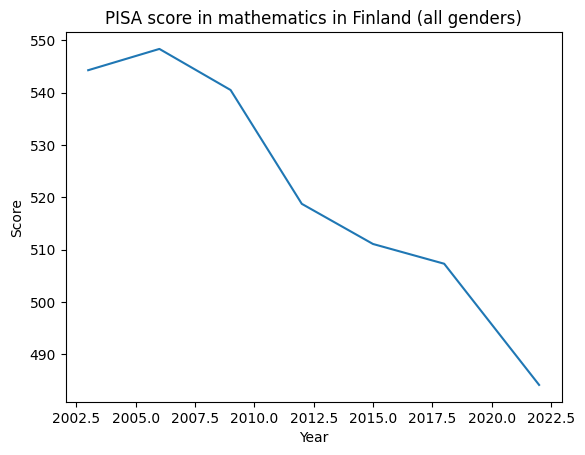

In [4]:
xs = years
ys = df.query('jurisdiction == "Finland" and gender == "all" and subject == "mathematics"')['average']
plt.plot(xs,ys)
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('PISA score in mathematics in Finland (all genders)')

So the plot suggests that mathematics scores have *plummeted* in Finland, they used to be high, now they're at rock bottom. But is this the truth?

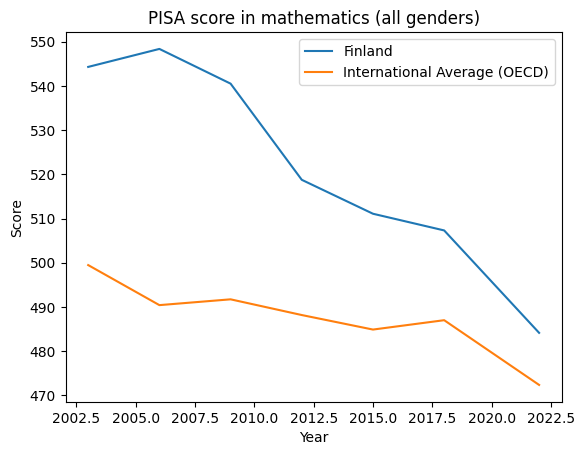

In [5]:
xs = years
for country in ['Finland', 'International Average (OECD)']:
    ys = df.query(f'jurisdiction == "{country}" and gender == "all" and subject == "mathematics"')['average']
    plt.plot(xs,ys,label=country)    
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('PISA score in mathematics (all genders)')
plt.legend()

Ok, so it's not *that* bad, Finland is still above OECD average. The initial plot was lying because the *y*-axis has been cut. Let's change the limits so that we see origin as well. Simultaneously, let's change *x*-axis ticks to respect that the measurements have been taken at three-year intervals.

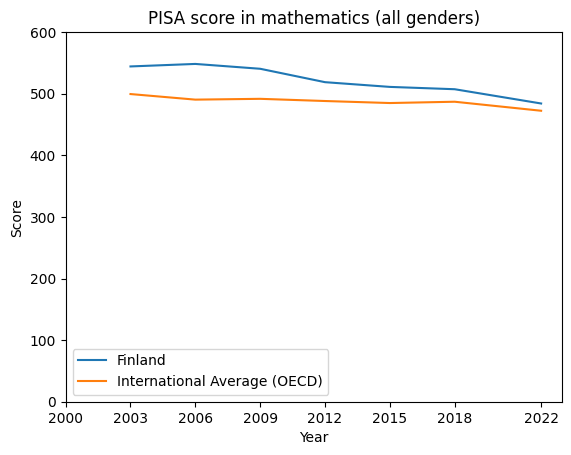

In [6]:
xs = years
for country in ['Finland', 'International Average (OECD)']:
    ys = df.query(f'jurisdiction == "{country}" and gender == "all" and subject == "mathematics"')['average']
    plt.plot(xs,ys,label=country)    
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('PISA score in mathematics (all genders)')
plt.ylim(0,600)
plt.xticks(years)
plt.legend()

Now we can see that there's a clear but not quite so dramatic drop. However, none of the countries has score in the 0–300 range, so we might argue that this figure downplays the drop.

Let's fit a trend line.

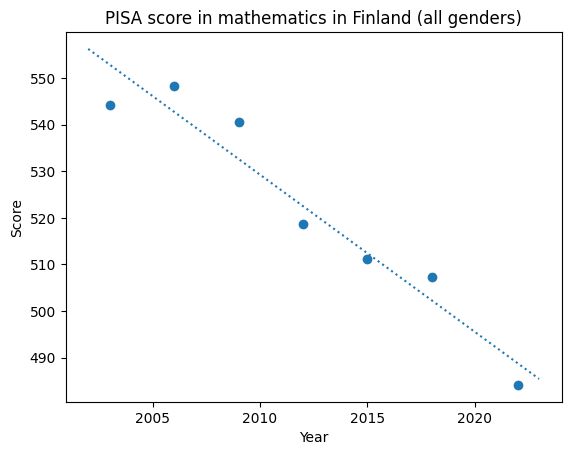

In [7]:
import numpy as np

ys = df.query('jurisdiction == "Finland" and gender == "all" and subject == "mathematics"')[['year','average']] \
    .dropna()
xs = ys['year']
ys = ys['average']
plt.scatter(xs,ys)
p = np.polyfit(xs,ys,1)
xs = np.arange(xs.min()-1,xs.max()+2)
plt.plot(xs,np.polyval(p,xs),linestyle=':')
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('PISA score in mathematics in Finland (all genders)')
plt.savefig('pisa_finland_trendline.pdf')

Let's have a relative look at other nordic countries next.

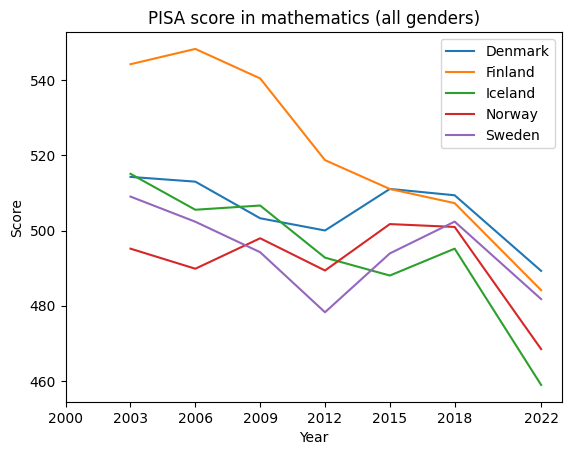

In [8]:
nordic_countries = ['Denmark','Finland','Iceland','Norway','Sweden']
xs = years
for country in nordic_countries:
    ys = df.query(f'jurisdiction == "{country}" and gender == "all" and subject == "mathematics"')['average']
    plt.plot(xs,ys,label=country)    
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('PISA score in mathematics (all genders)')
plt.xticks(years)
plt.legend()

What we are plotting here are *average scores* for the countries. How *certain* are we that the averages in 2018 were exactly in this order: Denmark, Finland, Sweden, Norway, Iceland? We already have some information about the uncertainty of measurements as we have the standard error. So let's include this in the plot. At the same time, we can include a *marker* to show that the values are recorded only at 3-year intervals and the lines in between do not represent actual observations in between.

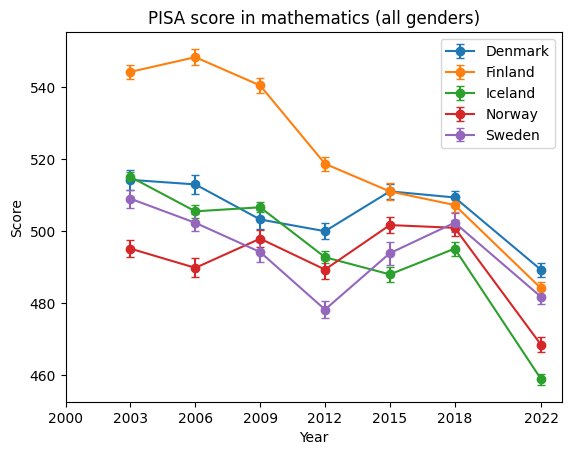

In [9]:
plt.rcParams.update({'text.usetex': False, 'font.family' : 'sans-serif'})
nordic_countries = ['Denmark','Finland','Iceland','Norway','Sweden']
xs = years
for country in nordic_countries:
    df2 = df.query(f'jurisdiction == "{country}" and gender == "all" and subject == "mathematics"')
    ys = df2['average']
    err = df2['std error']
    plt.errorbar(xs,ys,yerr=err,label=country,capsize=3,marker='o')
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('PISA score in mathematics (all genders)')
plt.xticks(years)
plt.legend()
plt.savefig('pisa_math_nordic_countries.pdf')

This reveals that there is quite sizable error in the observations so it is somewhat uncertain whether Denmark was really better than Finland, and whether Sweden was really better than Norway in 2018. However, we can be almost certain that Denmark did significantly better than Iceland in 2022.

Technically note that we now have three vectors of equal length: the x coordinate, y coordinate and the errorbar width. We also included a *cap* for the errorbar to make it more visible. The marker `'o'` produces filled circles. There are a lot of other options also that you can try out: `x`, `+`, `^`, `s`, `d` to name a few. See [here](https://matplotlib.org/stable/api/markers_api.html).

Point of contention: line styles. Some people argue that different lines should be made visible by employing different line styles, so that one need not rely on color to differentiate between different lines. On the other hand, this argument is largely from the era of printed paper when people regularly printed the papers and figures they used. Some authors suggest relying on color only for clarity because dashed or dotted lines can look messy. Use your best judgment. See [here](https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html).

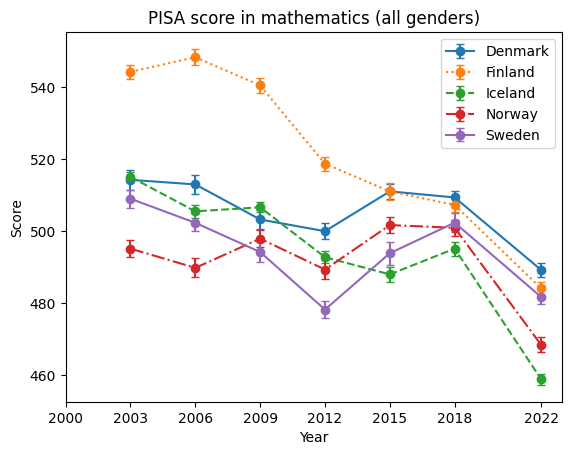

In [10]:
nordic_countries = ['Denmark','Finland','Iceland','Norway','Sweden']
linestyles = ['-',':','--','-.']
xs = years
for (i,country) in enumerate(nordic_countries):
    df2 = df.query(f'jurisdiction == "{country}" and gender == "all" and subject == "mathematics"')
    ys = df2['average']
    err = df2['std error']
    plt.errorbar(xs,ys,yerr=err,label=country,capsize=3,marker='o',linestyle = linestyles[i % len(linestyles)])
plt.xlabel('Year')
plt.ylabel('Score')
plt.title('PISA score in mathematics (all genders)')
plt.xticks(years)
plt.legend()

If we want to change the fonts to make use of LaTeX fonts (this increases rendering time a bit), we can do as follows.

Let's repeat this with seaborn. Seaborn admits `data`, `x`, and `y` parameters. `lineplot` produces the familiar lineplot.

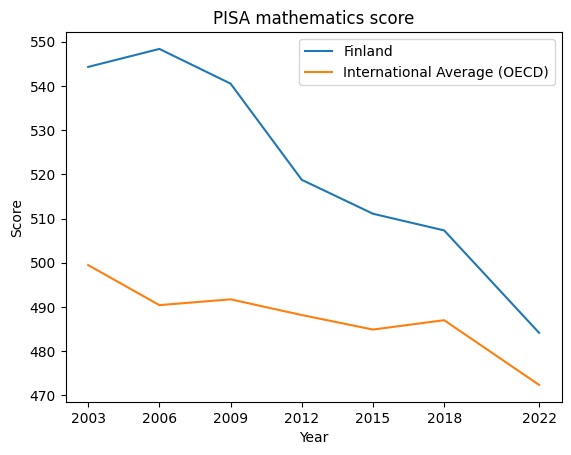

In [11]:
#plt.rcParams.update({'text.usetex': False, 'font.family' : 'sans-serif'})
import seaborn as sns
for country in ['Finland', 'International Average (OECD)']:
    df2 = df.query(f'jurisdiction == "{country}" and subject == "mathematics" and gender == "all"').dropna()
    g = sns.lineplot(data=df2,x='year',y='average',label=country)
g.set_xticks(df2['year'])
g.set_xticklabels(df2['year'])
g.set_xlabel('Year')
g.set_ylabel('Score')
g.set_title('PISA mathematics score')
g.legend()

This look pretty much the same as before. It is possible to adjust the style, as follows. Also, we'll make use of the `hue` feture which means that we don't need a loop.

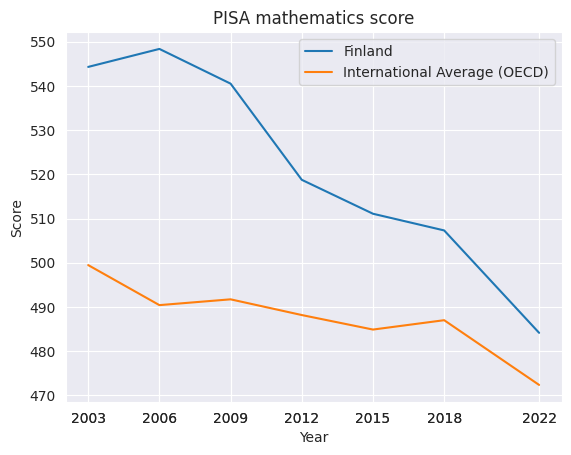

In [12]:
sns.set_style('darkgrid') # other presets are whitegrid, dark, white, and ticks
df2 = df.query(f'jurisdiction in ["Finland", "International Average (OECD)"] and subject == "mathematics" and gender == "all"').dropna()
g = sns.lineplot(data=df2,x='year',y='average',hue='jurisdiction')
g.set_xticks(df2['year'])
g.set_xticklabels(df2['year'])
g.set_xlabel('Year')
g.set_ylabel('Score')
g.set_title('PISA mathematics score')
g.legend()

This is a very cluttered style and is not recommended. Here's the full other example with a better style: white and ticks are a lot better choices if a grid is  not *absolutely* necessary.

Seaborn has elaborate functions to compute errorbars (and show them as nice looking shaded areas or spines), but it takes a bit juggling to use the precomputed data. This also makes it difficult to use the `hue` parameter in this setting.

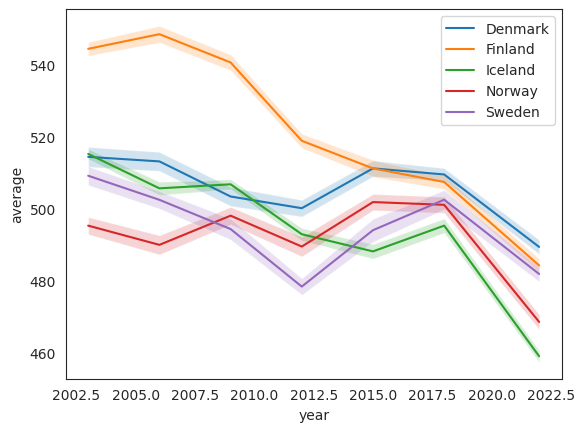

In [13]:
nordic_countries = ['Denmark','Finland','Iceland','Norway','Sweden']
sns.set_style('white') # other presets are whitegrid, dark, white, and ticks
df2 = df.query('jurisdiction in @nordic_countries and gender == "all" and subject == "mathematics"')
for country in nordic_countries:
    df3 = df2.query('jurisdiction == @country')
    g = sns.lineplot(data=df3,x="year",y="average",label=country)
    g.fill_between(df3['year'], df3['average']-df3['std error'], df3['average']+df3['std error'], alpha=0.2)

This is, however, misleading because it amplifies the message that there are values between datapoints. So this is ill-advised for this kind of data. So for this use case, using vanilla matplotlib is probably superior as there is no easy way to achieve the same in Seaborn. If we omit errorbars, we can do the following.

In [ ]:
nordic_countries = ['Denmark','Finland','Iceland','Norway','Sweden']
df2 = df.query('jurisdiction in @nordic_countries and gender == "all" and subject == "mathematics"')
g = sns.lineplot(data=df2,x="year",y="average",hue='jurisdiction',marker='o')
legend_handles, legend_labels = g.get_legend_handles_labels()
g.legend(legend_handles, legend_labels, title = 'Country')
g.set_xlabel('Year')
g.set_xticks(df2['year'].unique())
g.set_ylabel('Score')
g.set_title('PISA mathematics score in nordic countries')

In all cases, including seaborn cases, the figure can be saved by calling the `savefig` method of either the figure object (if one is available) or directly through the `plt` module.

In [ ]:
# like so:
# plt.savefig(filename.pdf)